In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [119]:
house = pd.read_csv("./HousePricing.csv", usecols=["FireplaceQu", "GarageQual", "SalePrice"])
house.sample(10)

,FireplaceQu,GarageQual,SalePrice
498,NaN,TA,130000
759,TA,TA,290000
1343,TA,Fa,177000
563,Gd,TA,185000
419,Fa,TA,142000
1420,TA,TA,179900
1179,Gd,NaN,93000
963,NaN,TA,239000
1333,NaN,TA,125500
1202,Fa,TA,117000


In [120]:
house.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

0    TA
Name: GarageQual, dtype: str

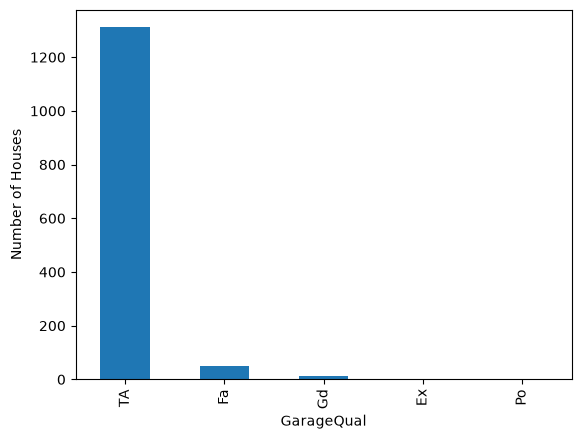

In [121]:
house["GarageQual"].value_counts().sort_values(ascending= False).plot(kind= "bar")
plt.xlabel("GarageQual")
plt.ylabel("Number of Houses")

house["GarageQual"].mode()

Text(0, 0.5, 'FireplaceQu')

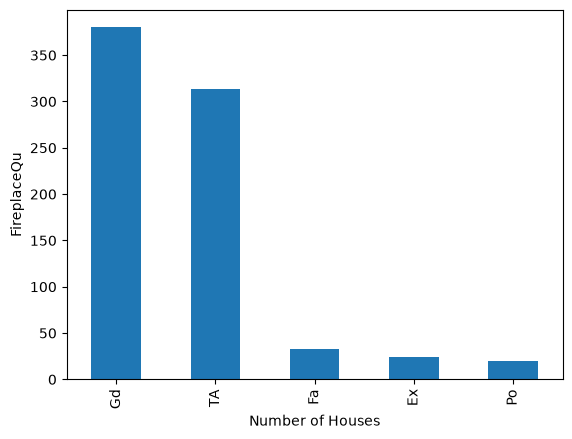

In [122]:
house["FireplaceQu"].value_counts().sort_values(ascending= False).plot.bar()
plt.xlabel("Number of Houses")
plt.ylabel("FireplaceQu")

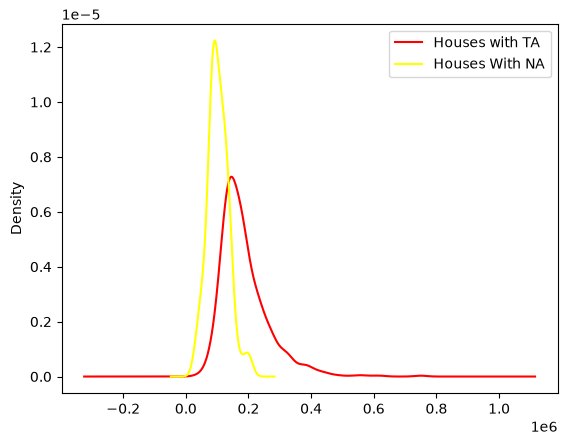

In [123]:
house[house["GarageQual"] == "TA"]["SalePrice"].plot(kind= "kde", color= "red")
house[house["GarageQual"].isnull()]["SalePrice"].plot.density(color= "yellow")
plt.legend(["Houses with TA", "Houses With NA"])
plt.show()

In [124]:
temp_garage = house[house["GarageQual"] == "TA"]["SalePrice"]

In [125]:
house["GarageQual"] = house["GarageQual"].fillna("TA", inplace= True)

C:\Users\aliab\AppData\Local\Temp\ipykernel_6904\3338880294.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  house["GarageQual"] = house["GarageQual"].fillna("TA", inplace= True)


In [126]:
house.isnull().sum()

FireplaceQu    690
GarageQual       0
SalePrice        0
dtype: int64

0    TA
Name: GarageQual, dtype: str

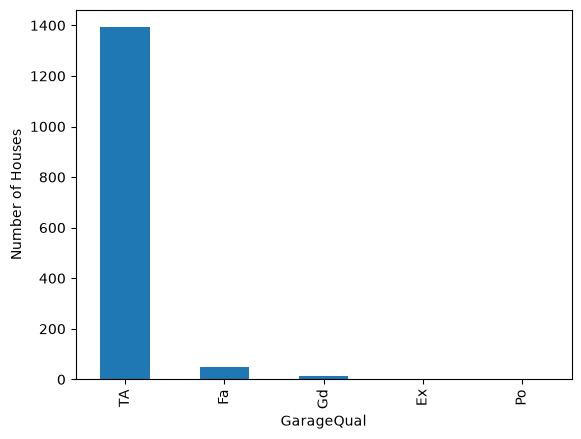

In [127]:
house["GarageQual"].value_counts().sort_values(ascending= False).plot(kind= "bar")
plt.xlabel("GarageQual")
plt.ylabel("Number of Houses")

house["GarageQual"].mode()

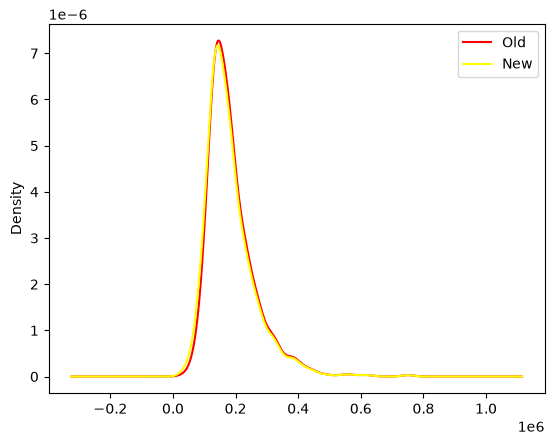

In [128]:
temp_garage.plot(kind= "kde", color= "red")
house[house["GarageQual"] == "TA"]["SalePrice"].plot(kind= "kde", color= "yellow")

plt.legend(["Old", "New"])
plt.show()

In [129]:
house = pd.read_csv("./HousePricing.csv", usecols=["FireplaceQu", "GarageQual", "SalePrice"])
house.sample(10)

,FireplaceQu,GarageQual,SalePrice
803,Gd,TA,582933
185,TA,Ex,475000
1322,TA,TA,190000
556,TA,TA,141000
421,TA,TA,215000
187,NaN,Fa,135000
928,TA,TA,236500
661,TA,TA,402000
1232,NaN,TA,101800
856,NaN,TA,147000


In [130]:
x = house.iloc[::, :2:]
y = house.iloc[::, -1]

In [131]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(x, y, test_size= 0.2, random_state= 42)

In [132]:
imp = skl.impute.SimpleImputer(strategy= "most_frequent")

x_train = imp.fit_transform(x_train)
x_test = imp.transform(x_test)

In [133]:
imp.statistics_

array(['Gd', 'TA'], dtype=object)

In [134]:
x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(x, y, test_size= 0.2, random_state= 42)

trf = skl.compose.ColumnTransformer(transformers= [
    ("imputer", skl.impute.SimpleImputer(strategy= "most_frequent"), ["GarageQual"])
    ], remainder= "passthrough")

x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

In [135]:
trf.named_transformers_["imputer"].statistics_

array(['TA'], dtype=object)